In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os


datadir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/Data/'
plotsdir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','steelblue','slateblue']
clrs = ['#a6611a','#67a9cf','#02818a']

3272 3272
100000
3272 3272
100000
102101 102101
0
102101 102101
0


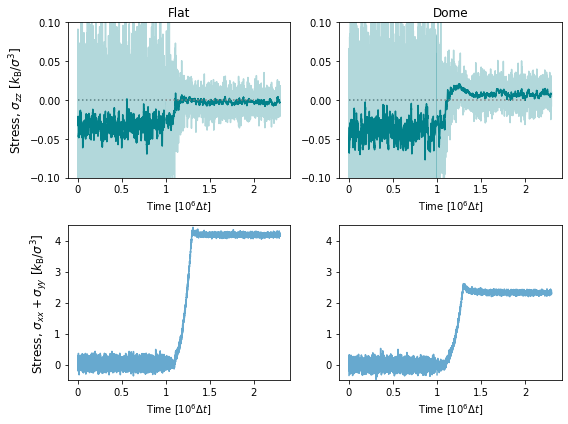

In [4]:
fig,ax = plt.subplots(2,2,figsize = (8,6))
#Timing inputs:
t_mix=0
t_stretch=30000
t_relax=100000
t_bonds=100000

xStretch = "60 30 76".split()
x=0

for ff in range(4):
    foldername = datadir
    if ff==0:
        filename = '/thermo_FlatStretch.dat' 
    elif ff==2:
        filename = '/thermo_DomeEqui.dat'
    elif ff==3:
        filename = '/thermo_FlatEqui.dat'
    elif ff==1:
        filename = '/thermo_DomeStretch.dat'
    
    thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
    etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
    etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce =etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
    Time_ = thermo.step
    Time = Time_.values
    
   # StressXTot.append(list(stressX))
   # AvBondForceXTot.append(list(AvBondForce))
    if ff==1 or ff==0:
        Time = np.add(Time,-100000)
    print(len(Time),len(stressX))
    Vol = 30*30*12 #165*165*12
    strain = float(xStretch[x])/30 #350/165
    VolTime = []
    tstrcount = 0
    for t in range(len(Time)):
        if Time[t] <= t_bonds:
            VolTime.append(Vol)
        if Time[t] > t_bonds and Time[t] <= t_bonds+t_stretch:
            VolTime.append(Vol+Vol*strain*((Time[tstrcount]-t_bonds)/t_stretch))
            tstrcount+=1
        if Time[t] > t_bonds + t_stretch:
            VolTime.append((1+strain)*Vol)
    print(Time[0])
    
    
    
    #ax[ff,1].plot(Time,np.zeros(len(Time)))
    stressTot = np.add(np.divide(stressY,VolTime),np.divide(stressX,VolTime))
    index_endstrain = 772
    N=30
    if ff <2:
        ax[1,ff].plot(Time[:index_endstrain],stressTot[:index_endstrain],color = clrs[1])
        ax[1,ff].plot(Time[index_endstrain+10:],stressTot[index_endstrain+10:],color = clrs[1])
        
        stressZAvNV = np.convolve(stressZ, np.ones(N)/N, mode='valid')
    
        stressZAv = np.convolve(np.divide(stressZ,VolTime), np.ones(N)/N, mode='valid')
        ax[0,ff].plot(Time[int(N/2)-1:-int(N/2)],stressZAv,color = clrs[2],label = 'Z')
        #ax[ff,2].plot(Time,stressZ,color = clrs[2],label = 'Z',alpha  =0.3)
        ax[0,ff].plot(Time,np.divide(stressZ,VolTime),color = clrs[2],label = 'Z',alpha = 0.3)
        ax[0,ff].set_ylim([-0.1,0.1])
        ax[1,ff].set_ylim([-0.5,4.5])
        ax[0,ff].plot([0,200000],[0,0],linestyle = ':',color = 'grey')
        #ax[ff,2].plot(Time[int(N/2)-1:-int(N/2)],stressZAvNV,color = clrs[2],label = 'Z',alpha  =1)
        #ax[0,ff].legend(frameon=False)
        ax[1,ff].set_xticks([0,50000,100000,150000,200000],['0','0.5','1','1.5','2'])
        ax[1,ff].set_xlabel('Time [$10^{6}\Delta t$]')
        ax[0,ff].set_xticks([0,50000,100000,150000,200000],['0','0.5','1','1.5','2'])
        ax[0,ff].set_xlabel('Time [$10^{6}\Delta t$]')
        #ax[ff,2].set_xticks([100000,150000,200000],['1','1.5','2'])
        #ax[ff,2].set_xlabel('Time [$10^{6}\Delta t$]')
        #ax[ff,0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
        #ax[ff,1].set_ylabel(r'Stress, $\sigma_{zz}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
    elif ff==2:
        TimeEnd=4950
        stressTot = np.add(np.divide(stressY,Vol),np.divide(stressX,Vol))
        stressZAvNV = np.convolve(stressZ, np.ones(N)/N, mode='valid')
        ax[1,1].plot(Time[:TimeEnd],stressTot[:TimeEnd],color = clrs[1])
        ax[0,1].plot(Time[:TimeEnd],np.divide(stressZ[:TimeEnd],Vol),color = clrs[2],alpha = 0.3)
        ax[0,1].plot(Time[:TimeEnd],np.divide(stressZAvNV[:TimeEnd],Vol),color = clrs[2],alpha = 1)

        #ax[1,0].plot(Time[:TimeEnd],stressTot[:TimeEnd],color = clrs[1])
        #ax[0,0].plot(Time[:TimeEnd],np.divide(stressZ[:TimeEnd],Vol),color = clrs[2],alpha = 0.3)
        #ax[0,0].plot(Time[:TimeEnd],np.divide(stressZAvNV[:TimeEnd],Vol),color = clrs[2],alpha = 1)
    elif ff==3:
        TimeEnd=4950 #4950
        stressTot = np.add(np.divide(stressY,Vol),np.divide(stressX,Vol))
        stressZAvNV = np.convolve(stressZ, np.ones(N)/N, mode='valid')
        ax[1,0].plot(Time[:TimeEnd],stressTot[:TimeEnd],color = clrs[1])
        ax[0,0].plot(Time[:TimeEnd],np.divide(stressZ[:TimeEnd],Vol),color = clrs[2],alpha = 0.3)
        ax[0,0].plot(Time[:TimeEnd],np.divide(stressZAvNV[:TimeEnd],Vol),color = clrs[2],alpha = 1)



ax[0,0].set_title('Flat')
ax[0,1].set_title('Dome')
ax[1,0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0,0].set_ylabel(r'Stress, $\sigma_{zz}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
fig.tight_layout()
plotname = 'FlatVsDome_zzStress.pdf'
#plotname = 'FlatVsDome_zzStress.png'
fig.savefig(plotsdir+plotname)